# Table Retrieval Evaluation

For each query (question) in the dataset, rank all unique tables by cosine similarity
between the **query embedding** and the **table document embedding**, then report:

- **MRR** — Mean Reciprocal Rank
- **Hit@k** — Fraction of queries where the correct table appears in the top-k results  (k ∈ {1, 3, 5, 10, 20})

**Document embedding** of a table = single embedding of the serialised table text  
(header row + all data rows, joined as pipe-separated text).

%run evaluate.py

In [1]:
%run evaluate.py

Table Retrieval Evaluation
Config : C:\Users\wtchuitc\Documents\GitHub\UTUEL\table_retrieval\config.yaml
Entries: 5
Output : C:\Users\wtchuitc\Documents\GitHub\UTUEL\table_retrieval\results

Entry 0  |  dataset: test_lookup_WikiSQL
Embedder type: custom
  [UTUEL] Loaded checkpoint: model.pt
  [UTUEL] label=UTUEL/all-MiniLM-L6-v2+pt  dim=384  device=cuda
Label: UTUEL/all-MiniLM-L6-v2+pt
Loading dataset from C:\Users\wtchuitc\Documents\GitHub\UTUEL\datasets\test_lookup_WikiSQL.jsonl …
  11,324 records loaded
  4,242 unique tables
Embedding 4,242 table documents …
  [UTUEL] 4242 tables → 1428996 U-paths
  [UTUEL] embedding 182,653 unique node texts …
  [UTUEL] loading node cache: D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_WikiSQL_sentence-transformers-all-MiniLM-L6-v2_fc6704d7f3.embed_cache.pt
  [UTUEL] cache: 1,624,008 texts  dim=384
  [UTUEL] all 182,653 node texts served from cache  (no embed call)
  [UTUEL] encode U-paths: 1428996/1428996
  [UTUEL] Global node index — node=2,857,992

Batches:   0%|          | 0/89 [00:00<?, ?it/s]

  [UTUEL] encode queries: 11324/11324
  done in 12.0s  shape=(11324, 384)

  Variant          MRR  Hit@1  Hit@3  Hit@5  Hit@10  Hit@20
  ----------  --------  -----  -----  -----  -----  -----
  node_a        0.3166  0.2243  0.3451  0.4109  0.5035  0.5953
  node_b        0.3118  0.2212  0.3411  0.4016  0.4922  0.5842
  both          0.3170  0.2259  0.3453  0.4090  0.5001  0.5941

  Computing TSR (Top-Score-Rank) metrics …
  [UTUEL] TSR eval: 11324/11324

  TSR space          MRR  Hit@1  Hit@3  Hit@5  Hit@10  Hit@20
  ------------  --------  ------  ------  ------  ------  ------
  tsr             0.6242  0.5264  0.6778  0.7398  0.8075  0.8666
  col_tsr         0.3662  0.2673  0.4040  0.4679  0.5592  0.6518
  row_tsr         0.3760  0.2753  0.4174  0.4825  0.5749  0.6590
  tbl_tsr         0.3163  0.2239  0.3448  0.4108  0.5034  0.5951

  Results saved → C:\Users\wtchuitc\Documents\GitHub\UTUEL\table_retrieval\results\UTUEL_all-MiniLM-L6-v2+pt.json
  Top-5 export saved → C:\Users\wtchuit

KeyboardInterrupt: 

In [1]:
%run report.py --results_dir "D:\UTUEL_OUTPUT\collect_results_revision\table_retrieval\results"

Loading results from D:\UTUEL_OUTPUT\collect_results_revision\table_retrieval\results …
CSV  → D:\UTUEL_OUTPUT\collect_results_revision\table_retrieval\results\report.csv
MD   → D:\UTUEL_OUTPUT\collect_results_revision\table_retrieval\results\report.md
HTML → D:\UTUEL_OUTPUT\collect_results_revision\table_retrieval\results\report.html

TABLE RETRIEVAL — MODEL COMPARISON
| model                                     | type        | dataset                               | n_queries | n_tables | embed_time_s | MRR    | Hit@1  | Hit@3  | Hit@5  | Hit@10 | Hit@20 | tbl_MRR | tbl_Hit@1 | tbl_Hit@3 | tbl_Hit@5 | tbl_Hit@10 | tbl_Hit@20 |
| ----------------------------------------- | ----------- | ------------------------------------- | --------- | -------- | ------------ | ------ | ------ | ------ | ------ | ------ | ------ | ------- | --------- | --------- | --------- | ---------- | ---------- |
| UTUEL/embeddinggemma+pt                   | custom      | test_lookup_WikiSQL                   |

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from embedder import build_embedder
from evaluate import PROJECT_ROOT, extract_unique_tables, load_jsonl
import torch
import yaml
from sklearn.preprocessing import normalize

trl_dir = PROJECT_ROOT / "TRL-model"
if str(trl_dir) not in sys.path:
    sys.path.insert(0, str(trl_dir))
from smp import generate_u_paths_flat  # type: ignore[import]

CONFIG_CANDIDATES = [
    PROJECT_ROOT / "table_retrieval" / "config_embed_asses.yml",
    PROJECT_ROOT / "table_retrieval" / "config_embed_asses.yaml",
]
CONFIG_PATH = next((p for p in CONFIG_CANDIDATES if p.exists()), None)
if CONFIG_PATH is None:
    raise FileNotFoundError(
        "Could not find table_retrieval/config_embed_asses.yml or table_retrieval/config_embed_asses.yaml"
    )

with CONFIG_PATH.open(encoding="utf-8") as fh:
    config_embed_asses = yaml.safe_load(fh)

CHECKPOINTS_ROOT = Path(str(config_embed_asses.get("checkpoints_dir", "")).strip())
CACHE_ROOT = Path(str(config_embed_asses.get("cache_dir", "")).strip())
MAX_CELL_POINTS = None
EMBEDDING_SPACE = "cell_level_nodes_avg"

all_dataset_entries = config_embed_asses.get("datasets", [])
utuel_entries = []
for entry in all_dataset_entries:
    emb_cfg = dict(entry.get("embedder", {}))
    if emb_cfg.get("type") != "custom" or emb_cfg.get("class") != "UTUELTableEmbedder":
        continue
    utuel_entries.append((dict(entry), emb_cfg))

if not utuel_entries:
    raise RuntimeError(f"No UTUELTableEmbedder entries found in {CONFIG_PATH}")

def _resolve_path(raw_path: str | Path) -> Path:
    p = Path(raw_path)
    return p if p.is_absolute() else PROJECT_ROOT / p

all_dataset_paths = []
for entry, _ in utuel_entries:
    dataset_raw = str(entry.get("path", "")).strip()
    if dataset_raw:
        all_dataset_paths.append(_resolve_path(dataset_raw))

if not all_dataset_paths:
    raise RuntimeError(f"No dataset paths found in {CONFIG_PATH}")

DATASET_FILE = all_dataset_paths[0]
if any(path != DATASET_FILE for path in all_dataset_paths[1:]):
    raise RuntimeError("Cell 6 expects one shared dataset path across UTUEL entries in config_embed_asses")

def _resolve_cfg(emb_cfg: dict) -> dict:
    cfg = dict(emb_cfg)
    ckpt_path = Path(str(cfg.get("checkpoint_dir", "")).strip())
    if ckpt_path and not ckpt_path.is_absolute():
        cfg["checkpoint_dir"] = str(CHECKPOINTS_ROOT / ckpt_path)
    cache_path = Path(str(cfg.get("cache_file", "")).strip())
    if cache_path and not cache_path.is_absolute():
        cfg["cache_file"] = str(CACHE_ROOT / cache_path)
    return cfg

def _flatten_upaths(records: list[dict]) -> list:
    flat_upaths = []
    for rec in records:
        header = [str(h) for h in rec.get("header", [])]
        rows = [[str(c) for c in row] for row in rec.get("rows", [])]
        flat_upaths.extend(generate_u_paths_flat(header, rows))
    return flat_upaths

def _build_node_index(flat_upaths: list):
    text_to_idx = {}
    for up in flat_upaths:
        for text in (up.col_header_a, up.cell_value_a, up.cell_value_b, up.col_header_b):
            if text not in text_to_idx:
                text_to_idx[text] = len(text_to_idx)
    all_texts = list(text_to_idx.keys())
    pa_idx = np.asarray([text_to_idx[up.col_header_a] for up in flat_upaths], dtype=np.int64)
    na_idx = np.asarray([text_to_idx[up.cell_value_a] for up in flat_upaths], dtype=np.int64)
    nb_idx = np.asarray([text_to_idx[up.cell_value_b] for up in flat_upaths], dtype=np.int64)
    pb_idx = np.asarray([text_to_idx[up.col_header_b] for up in flat_upaths], dtype=np.int64)
    return all_texts, pa_idx, na_idx, nb_idx, pb_idx

def _build_init_embedding(embedder, flat_upaths: list) -> np.ndarray:
    all_texts, pa_idx, na_idx, _, _ = _build_node_index(flat_upaths)
    node_embs_np = embedder._get_node_embeddings_cached(all_texts)
    init_arr = np.concatenate([node_embs_np[pa_idx], node_embs_np[na_idx]], axis=0)
    init_arr = normalize(init_arr).astype(np.float32)

    # if MAX_CELL_POINTS is not None and init_arr.shape[0] > MAX_CELL_POINTS:
    #     rng = np.random.default_rng(42)
    #     pick = rng.choice(init_arr.shape[0], size=MAX_CELL_POINTS, replace=False)
    #     init_arr = init_arr[pick]

    return init_arr

def _encode_cell_level_nodes_avg(embedder, flat_upaths: list) -> np.ndarray:
    all_texts, pa_idx, na_idx, nb_idx, pb_idx = _build_node_index(flat_upaths)
    node_embs_np = embedder._get_node_embeddings_cached(all_texts)

    smp_np = np.stack(
        [
            node_embs_np[pa_idx],
            node_embs_np[na_idx],
            node_embs_np[nb_idx],
            node_embs_np[pb_idx],
        ],
        axis=1,
    )

    all_node_a = []
    all_node_b = []
    total_upaths = smp_np.shape[0]

    with torch.no_grad():
        for start in range(0, total_upaths, embedder.batch_size):
            chunk_np = smp_np[start : start + embedder.batch_size]
            chunk = torch.tensor(chunk_np, dtype=torch.float32, device=embedder.device)
            node_a, node_b = embedder._encode_smp_chunk(chunk)
            all_node_a.append(node_a.cpu())
            all_node_b.append(node_b.cpu())
            done = min(start + embedder.batch_size, total_upaths)
            print(f"  [UTUEL] encode U-paths: {done}/{total_upaths}", end="\r", flush=True)
    print()

    node_a_np = torch.cat(all_node_a, dim=0).numpy().astype(np.float32)
    header_a_np = node_embs_np[pa_idx].astype(np.float32)
    emb_arr = np.concatenate([header_a_np, node_a_np], axis=0)
    emb_arr = normalize(emb_arr).astype(np.float32)

    # if MAX_CELL_POINTS is not None and emb_arr.shape[0] > MAX_CELL_POINTS:
    #     rng = np.random.default_rng(42)
    #     pick = rng.choice(emb_arr.shape[0], size=MAX_CELL_POINTS, replace=False)
    #     emb_arr = emb_arr[pick]

    return emb_arr

records = load_jsonl(DATASET_FILE)
_, unique_records = extract_unique_tables(records)
print(f"Using config: {CONFIG_PATH}")
print(f"Using checkpoints root: {CHECKPOINTS_ROOT}")
print(f"Using cache root: {CACHE_ROOT}")
print(f"Loaded {len(records)} rows -> {len(unique_records)} unique tables from {DATASET_FILE}")
print(f"Loaded {len(utuel_entries)} UTUEL entries from config")

flat_upaths = _flatten_upaths(unique_records)
model_variant_embeddings: dict[str, dict[str, np.ndarray]] = {}
model_init_embeddings: dict[str, np.ndarray] = {}
model_meta: list[dict] = []

for entry, emb_cfg in utuel_entries:
    model_name_full = str(emb_cfg.get("model_name", "")).strip()
    model_prefix = model_name_full.split("UTUEL/", 1)[1] if model_name_full.startswith("UTUEL/") else model_name_full
    entry_name = str(entry.get("name", "")).strip()
    variant = entry_name.split("__", 1)[1] if "__" in entry_name else entry_name or model_prefix
    run_name = entry_name or f"{model_prefix}__{variant}"
    resolved_cfg = _resolve_cfg(emb_cfg)

    model_variant_embeddings.setdefault(model_prefix, {})

    print(f"\n[embed] {run_name}")
    print(f"        checkpoint_dir(raw): {emb_cfg.get('checkpoint_dir', '')}")
    print(f"        checkpoint_dir(resolved): {resolved_cfg.get('checkpoint_dir', '')}")
    print(f"        cache_file(raw): {emb_cfg.get('cache_file', '')}")
    print(f"        cache_file(resolved): {resolved_cfg.get('cache_file', '')}")

    emb_obj = build_embedder(resolved_cfg, project_root=PROJECT_ROOT)

    if model_prefix not in model_init_embeddings:
        init_arr = _build_init_embedding(emb_obj, flat_upaths)
        model_init_embeddings[model_prefix] = init_arr
        print(f"        init embedding shape (index-aligned): {init_arr.shape}")

    emb_arr = _encode_cell_level_nodes_avg(emb_obj, flat_upaths)
    model_variant_embeddings[model_prefix][variant] = emb_arr

    print(f"        embedding space: {EMBEDDING_SPACE}")
    print(f"        embeddings shape: {emb_arr.shape}")

    model_meta.append(
        {
            "name": run_name,
            "model_prefix": model_prefix,
            "variant": variant,
            "embedding_space": EMBEDDING_SPACE,
            "checkpoint_dir_raw": emb_cfg.get("checkpoint_dir", ""),
            "checkpoint_dir_resolved": resolved_cfg.get("checkpoint_dir", ""),
            "cache_file_raw": emb_cfg.get("cache_file", ""),
            "cache_file_resolved": resolved_cfg.get("cache_file", ""),
            "shape": tuple(emb_arr.shape),
        }
    )

display(pd.DataFrame(model_meta))

Using config: C:\Users\wtchuitc\Documents\GitHub\UTUEL\table_retrieval\config_embed_asses.yaml
Using checkpoints root: D:\UTUEL_OUTPUT\collect_results_revision\checkpoints
Using cache root: D:\UTUEL_OUTPUT\cache_embeddings
Loaded 10 rows -> 5 unique tables from D:\TABLE_DATASET\WIKI_TABLE_SQL\test_lookup_test_jepa_arch.jsonl
Loaded 20 UTUEL entries from config

[embed] all-MiniLM-L6-v2__all_losses_active
        checkpoint_dir(raw): all-MiniLM-L6-v2\2026-06-05_03-28-45_4f036259\final
        checkpoint_dir(resolved): D:\UTUEL_OUTPUT\collect_results_revision\checkpoints\all-MiniLM-L6-v2\2026-06-05_03-28-45_4f036259\final
        cache_file(raw): test_lookup_WikiSQL_sentence-transformers-all-MiniLM-L6-v2_fc6704d7f3.embed_cache.pt
        cache_file(resolved): D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_WikiSQL_sentence-transformers-all-MiniLM-L6-v2_fc6704d7f3.embed_cache.pt
  [UTUEL] Loaded checkpoint: model.pt
  [UTUEL] label=UTUEL/all-MiniLM-L6-v2+pt  dim=384  device=cuda
  [UTUEL] lo

KeyboardInterrupt: 

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (81) found smaller than n_clusters (82). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (91) found smaller than n_clusters (92). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (101) found smaller than n_clusters (102). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (109) found smaller than n_clusters (112). Possibl

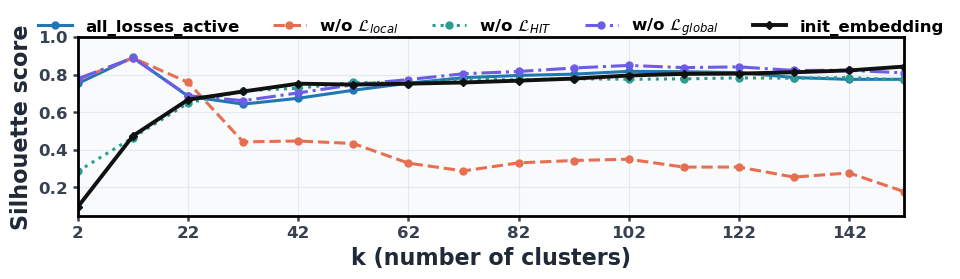

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (71) found smaller than n_clusters (72). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (90) found smaller than n_clusters (92). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (99) found smaller than n_clusters (102). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (105) found smaller than n_clusters (112). Possibly

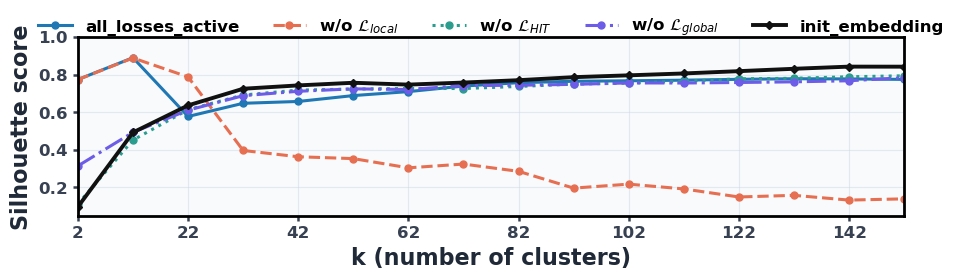

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (71) found smaller than n_clusters (72). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (81) found smaller than n_clusters (82). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (88) found smaller than n_clusters (92). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (100) found smaller than n_clusters (102). Possibly 

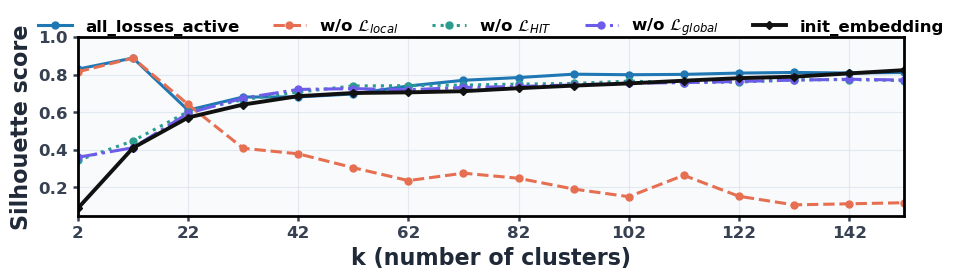

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (31) found smaller than n_clusters (32). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (41) found smaller than n_clusters (42). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (50) found smaller than n_clusters (52). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (57) found smaller than n_clusters (62). Possibly du

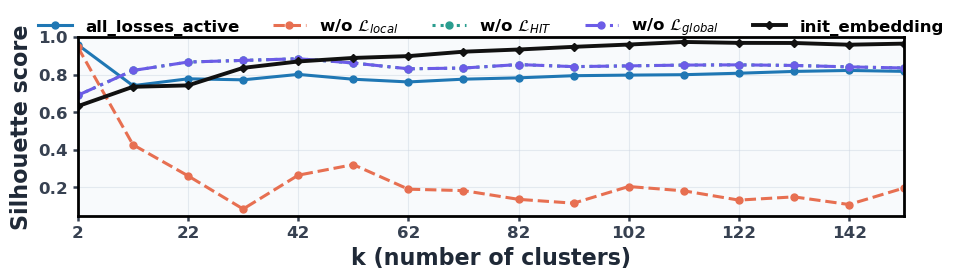

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (80) found smaller than n_clusters (82). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (100) found smaller than n_clusters (102). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (107) found smaller than n_clusters (112). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (115) found smaller than n_clusters (122). Possi

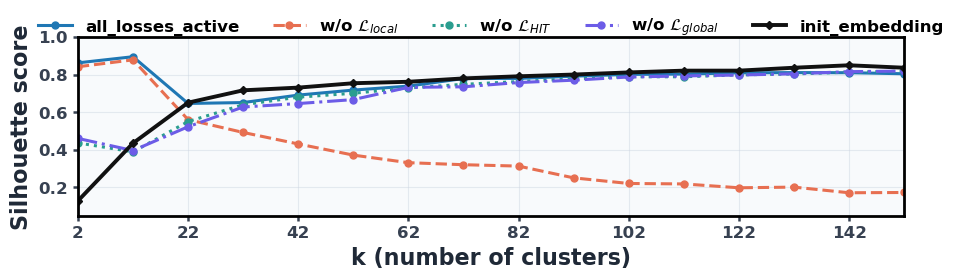


Saved silhouette files:
 - silhouette_all-MiniLM-L6-v2_variants.png
 - silhouette_all-MiniLM-L6-v2_variants.pdf
 - silhouette_all-minilm_variants.png
 - silhouette_all-minilm_variants.pdf
 - silhouette_embeddinggemma_variants.png
 - silhouette_embeddinggemma_variants.pdf
 - silhouette_nomic-embed-text_variants.png
 - silhouette_nomic-embed-text_variants.pdf
 - silhouette_qwen3-embedding_0.6b_variants.png
 - silhouette_qwen3-embedding_0.6b_variants.pdf

Model embeddings used:


,name,model_prefix,variant,embedding_space,checkpoint_dir_raw,checkpoint_dir_resolved,cache_file_raw,cache_file_resolved,shape
0,all-MiniLM-L6-v2__all_losses_active,all-MiniLM-L6-v2,all_losses_active,cell_level_nodes_avg,all-MiniLM-L6-v2\2026-06-05_03-28-45_4f036259\...,D:\UTUEL_OUTPUT\collect_results_revision\check...,test_lookup_WikiSQL_sentence-transformers-all-...,D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_W...,"(3618, 384)"
1,qwen3-embedding:0.6b__all_losses_active,qwen3-embedding:0.6b,all_losses_active,cell_level_nodes_avg,qwen3-embedding#0.6b\2026-06-05_02-14-47_33fc1...,D:\UTUEL_OUTPUT\collect_results_revision\check...,test_lookup_WikiSQL_qwen3-embedding_0.6b_58e39...,D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_W...,"(3618, 768)"
2,nomic-embed-text__all_losses_active,nomic-embed-text,all_losses_active,cell_level_nodes_avg,nomic-embed-text\2026-06-05_06-23-52_b2126004\...,D:\UTUEL_OUTPUT\collect_results_revision\check...,test_lookup_WikiSQL_nomic-embed-text_56d7a476d...,D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_W...,"(3618, 768)"
3,all-minilm__all_losses_active,all-minilm,all_losses_active,cell_level_nodes_avg,all-minilm\2026-06-04_23-25-55_2cb37ccf\final,D:\UTUEL_OUTPUT\collect_results_revision\check...,test_lookup_WikiSQL_all-minilm_901d8e9ffc.embe...,D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_W...,"(3618, 384)"
4,embeddinggemma__all_losses_active,embeddinggemma,all_losses_active,cell_level_nodes_avg,embeddinggemma\2026-06-04_23-48-58_50881565\final,D:\UTUEL_OUTPUT\collect_results_revision\check...,test_lookup_WikiSQL_embeddinggemma_13fcc3d7b9....,D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_W...,"(3618, 768)"
5,all-MiniLM-L6-v2__local_off,all-MiniLM-L6-v2,local_off,cell_level_nodes_avg,all-MiniLM-L6-v2\2026-06-04_22-14-11_57341149\...,D:\UTUEL_OUTPUT\collect_results_revision\check...,test_lookup_WikiSQL_sentence-transformers-all-...,D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_W...,"(3618, 384)"
6,qwen3-embedding:0.6b__local_off,qwen3-embedding:0.6b,local_off,cell_level_nodes_avg,qwen3-embedding#0.6b\2026-06-04_22-08-43_c7aeb...,D:\UTUEL_OUTPUT\collect_results_revision\check...,test_lookup_WikiSQL_qwen3-embedding_0.6b_58e39...,D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_W...,"(3618, 768)"
7,nomic-embed-text__local_off,nomic-embed-text,local_off,cell_level_nodes_avg,nomic-embed-text\2026-06-04_22-09-42_b2f2d762\...,D:\UTUEL_OUTPUT\collect_results_revision\check...,test_lookup_WikiSQL_nomic-embed-text_56d7a476d...,D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_W...,"(3618, 768)"
8,all-minilm__local_off,all-minilm,local_off,cell_level_nodes_avg,all-minilm\2026-06-04_22-10-19_e157b4d0\final,D:\UTUEL_OUTPUT\collect_results_revision\check...,test_lookup_WikiSQL_all-minilm_901d8e9ffc.embe...,D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_W...,"(3618, 384)"
9,embeddinggemma__local_off,embeddinggemma,local_off,cell_level_nodes_avg,embeddinggemma\2026-06-04_21-54-41_31b08882\final,D:\UTUEL_OUTPUT\collect_results_revision\check...,test_lookup_WikiSQL_embeddinggemma_13fcc3d7b9....,D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_W...,"(3618, 768)"


In [16]:
# ── Silhouette plots (one image per model, variants overlaid) ───────────────
from multiprocessing.spawn import prepare

from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


colors = ["#1f77b4", "#e76f51", "#2a9d8f", "#6c5ce7", "#f4a261", "#264653"]
linestyles = ["-", "--", ":", "-.", "-", "--"]
k_range = range(2, 153, 10)
N_COMPONENTS = 50

variant_order = ["all_losses_active", "local_off", "hit_off", "global_off"]

label_dict = {
	"all_losses_active": "all_losses_active",
	"local_off": "w/o $\mathcal{L}_{local}$",
	"hit_off": "w/o $\mathcal{L}_{HIT}$",
	"global_off": "w/o $\mathcal{L}_{global}$",
	"init_embedding": "init_embedding",}
saved_files = []

for model_prefix in sorted(model_variant_embeddings.keys()):
    fig, ax = plt.subplots(figsize=(10.0, 3), facecolor="white")
    ax.set_facecolor("#f8fafc")

    variant_map = model_variant_embeddings[model_prefix]
    ordered_variants = [v for v in variant_order if v in variant_map] + [v for v in sorted(variant_map.keys()) if v not in variant_order]

    min_k_seen = float("inf")
    max_k_seen = float("-inf")
    n_plotted = 0

    for idx, variant in enumerate(ordered_variants):
        emb = variant_map[variant]
        color = colors[idx % len(colors)]
        ls = linestyles[idx % len(linestyles)]

        emb_reduced = PCA(n_components=N_COMPONENTS,random_state=42).fit_transform(emb)
        scores = []
        max_k = min(max(k_range), emb_reduced.shape[0] - 1)
        if max_k < 2:
            print(f"[skip] {model_prefix}::{variant} - not enough points for silhouette analysis")
            continue

        ks = [k for k in k_range if k <= max_k]
        for k in ks:
            labels = KMeans(n_clusters=k, random_state=42, n_init="auto").fit_predict(emb_reduced)
            scores.append(silhouette_score(emb_reduced, labels, metric="cosine"))

        min_k_seen = min(min_k_seen, min(ks))
        max_k_seen = max(max_k_seen, max(ks))
        n_plotted += 1

        ax.plot(
            ks,
            scores,
            label=label_dict.get(variant, variant),
            color=color,
            linestyle=ls,
            linewidth=2.2,
            marker="o",
            markersize=5,
        )

    init_emb = model_init_embeddings.get(model_prefix)
    if init_emb is not None:
        # Keep strict row alignment with finetuned node space for fair comparison.
        target_n = next((v.shape[0] for v in variant_map.values()), None)
        if target_n is not None and init_emb.shape[0] != target_n:
            print(f"[warn] {model_prefix}::init_embedding shape {init_emb.shape[0]} != output shape {target_n}; skipping init curve")
        else:
            init_reduced = PCA(n_components=N_COMPONENTS, random_state=42).fit_transform(init_emb)
            init_scores = []
            init_max_k = min(max(k_range), init_reduced.shape[0] - 1)
            if init_max_k >= 2:
                init_ks = [k for k in k_range if k <= init_max_k]
                for k in init_ks:
                    labels = KMeans(n_clusters=k, random_state=42, n_init="auto").fit_predict(init_reduced)
                    init_scores.append(silhouette_score(init_reduced, labels, metric="cosine"))

                min_k_seen = min(min_k_seen, min(init_ks))
                max_k_seen = max(max_k_seen, max(init_ks))
                n_plotted += 1

                ax.plot(
                    init_ks,
                    init_scores,
                    label="init_embedding",
                    color="#111111",
                    linestyle="-",
                    linewidth=2.8,
                    marker="D",
                    markersize=4,
                )
            else:
                print(f"[skip] {model_prefix}::init_embedding - not enough points for silhouette analysis")

    if n_plotted == 0:
        plt.close(fig)
        print(f"[skip] {model_prefix} - no embedding space had enough points to plot")
        continue

    x_min = int(min_k_seen)
    x_max = int(max_k_seen)
    ax.set_xlim(x_min, x_max)
    ax.set_xticks(list(range(x_min, x_max + 1, 20)))

    ax.set_ylim(0.05, 1.0)

    ax.set_xlabel("k (number of clusters)", fontsize=16, color="#1f2937", fontweight="bold")
    ax.set_ylabel("Silhouette score", fontsize=16, color="#1f2937", fontweight="bold")
    # ax.set_title(f"UTUEL/{model_prefix} (cell-level space)", color="#111827", fontsize=15)

    ax.tick_params(colors="#374151", labelsize=12, width=1.8)
    plt.setp(ax.get_xticklabels(), fontweight="bold")
    plt.setp(ax.get_yticklabels(), fontweight="bold")
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(2.0)
    ax.grid(alpha=0.45, color="#cbd5e1", linewidth=0.8)
    ax.legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.20),
        ncol=min(len(ordered_variants) + 1, 5),
        prop={"weight": "bold", "size": 12},
    )

    safe_name = model_prefix.replace("/", "_").replace(":", "_").replace("#", "_").replace(" ", "_")
    png_path = f"silhouette_{safe_name}_variants.png"
    pdf_path = f"silhouette_{safe_name}_variants.pdf"
    plt.tight_layout()
    plt.savefig(pdf_path, dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.savefig(png_path, dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
    saved_files.extend([png_path, pdf_path])
    plt.show()

print("\nSaved silhouette files:")
for p in saved_files:
    print(" -", p)

print("\nModel embeddings used:")
display(pd.DataFrame(model_meta))

In [ ]:

# Build cached query embeddings per model/variant for per-table visualization.
# Reads raw query embeddings from pre-computed JSON files in:
#   D:\UTUEL_OUTPUT\cache_embeddings\query_embeddings\
# Structure:
#   queries.json              — list of query strings (shared across models)
#   {model_name}.json         — {"model": "...", "embeddings": [[...], ...], ...}
# Variant (encoder-output) spaces are computed by passing cached raw vecs
# through the local PyTorch transformer only.

import json
from pathlib import Path
from collections import defaultdict
import numpy as np
import torch8*;l;-
import torch.nn.functional as F
from sklearn.preprocessing import normalize

if "utuel_entries" not in globals():
    raise RuntimeError("Run Cell 6 first (UTUEL loading cell).")
if "records" not in globals() or "model_variant_embeddings" not in globals() or "model_init_embeddings" not in globals():
    raise RuntimeError("Run Cell 6 first so all caches are populated.")

# ── Query embedding JSON directory ───────────────────────────────────────────
QUERY_EMBEDDINGS_DIR = Path(r"D:\UTUEL_OUTPUT\cache_embeddings\query_embeddings")
MAX_EMBED_DIM = 768  # always project to min(current_dim, MAX_EMBED_DIM)

# ── Per-table query index mapping ────────────────────────────────────────────
query_records = [r for r in records if str(r.get("question", "")).strip()]
queries = [str(r.get("question", "")).strip() for r in query_records]
if not queries:
    raise RuntimeError("No query text found in dataset records.")

query_record_table_ids = [str(r.get("table_id", "")) for r in query_records]
query_indices_by_table = defaultdict(list)
for q_idx, tid in enumerate(query_record_table_ids):
    query_indices_by_table[tid].append(q_idx)
query_indices_by_table = {k: np.asarray(v, dtype=np.int64) for k, v in query_indices_by_table.items()}

# ── Helpers ───────────────────────────────────────────────────────────────────

def _model_name_to_json_stem(model_name: str) -> str:
    """Map a UTUEL base model name to its query-embedding JSON stem.

    Examples:
      'UTUEL/all-minilm'           -> 'all-minilm'
      'UTUEL/qwen3-embedding:0.6b' -> 'qwen3-embedding_0.6b'
    """
    stem = model_name.split("UTUEL/", 1)[-1]
    stem = stem.replace(":", "_")
    return stem


def _raw_from_json(texts: list[str], model_name: str) -> np.ndarray | None:
    """Load raw query embeddings from the pre-computed JSON cache.

    Matches each text in *texts* against the canonical queries.json list and
    returns the corresponding rows from the model-specific embedding JSON.
    Embeddings are always sliced to min(current_dim, MAX_EMBED_DIM) and
    re-normalized before use.
    Returns an [N, D] float32 array, or None on any cache miss.
    """
    stem = _model_name_to_json_stem(model_name)
    json_path = QUERY_EMBEDDINGS_DIR / f"{stem}.json"
    queries_path = QUERY_EMBEDDINGS_DIR / "queries.json"

    if not queries_path.exists():
        print(f"  [cache miss] queries.json not found: {queries_path}")
        return None
    if not json_path.exists():
        print(f"  [cache miss] embedding JSON not found: {json_path}")
        return None

    with queries_path.open(encoding="utf-8") as fh:
        cached_queries: list[str] = json.load(fh)

    with json_path.open(encoding="utf-8") as fh:
        model_data: dict = json.load(fh)

    embeddings: list[list[float]] = model_data.get("embeddings", [])
    if len(embeddings) != len(cached_queries):
        print(f"  [cache miss] embeddings count {len(embeddings)} != queries count {len(cached_queries)} in {json_path.name}")
        return None

    text_to_idx: dict[str, int] = {q: i for i, q in enumerate(cached_queries)}
    missing = [t for t in texts if t not in text_to_idx]
    if missing:
        print(f"  [cache miss] {len(missing)}/{len(texts)} queries not in {json_path.name}; skipping")
        return None

    idx_list = [text_to_idx[t] for t in texts]
    arr = np.array([embeddings[i] for i in idx_list], dtype=np.float32)

    target_dim = min(arr.shape[1], MAX_EMBED_DIM)
    if target_dim < arr.shape[1]:
        print(f"  [truncate] embedding dim {arr.shape[1]} > {MAX_EMBED_DIM}; truncating to {target_dim}")
    arr = arr[:, :target_dim]
    arr = normalize(arr)

    return arr


def _resolve_cfg(emb_cfg: dict) -> dict:
    resolved = dict(emb_cfg)
    ckpt_raw = str(emb_cfg.get("checkpoint_dir", "")).strip()
    cache_raw = str(emb_cfg.get("cache_file", "")).strip()
    if ckpt_raw:
        p = Path(ckpt_raw)
        resolved["checkpoint_dir"] = str(p if p.is_absolute() else CHECKPOINTS_ROOT / p)
    if cache_raw:
        p = Path(cache_raw)
        resolved["cache_file"] = str(p if p.is_absolute() else CACHE_ROOT / p)
    return resolved

def _encode_queries_from_raw(embedder, raw_vecs: np.ndarray) -> np.ndarray:
    """Pass pre-computed base embeddings through the local transformer encoder."""
    m = embedder.trl_model
    batch_size = int(getattr(embedder, "batch_size", 128))
    out: list[np.ndarray] = []
    for i in range(0, len(raw_vecs), batch_size):
        chunk = torch.tensor(raw_vecs[i : i + batch_size], dtype=torch.float32, device=embedder.device)
        with torch.no_grad():
            q_proj = m.input_projection(chunk.unsqueeze(1))  # [B, 1, d_out]
            enc_q, _, _ = m.transformer_encoder(q_proj)      # [B, 1, d_out]
            q_norm = F.normalize(enc_q[:, 0, :], dim=-1)     # [B, d_out]
        out.append(q_norm.cpu().numpy())
    return np.concatenate(out, axis=0).astype(np.float32)

# ── Build per-model variant list ──────────────────────────────────────────────
# Group all entries by model_prefix so we load the cache once per model.
entries_by_model: dict[str, list[tuple[str, dict]]] = defaultdict(list)
for entry, emb_cfg in utuel_entries:
    model_name_full = str(emb_cfg.get("model_name", ""))
    model_prefix = model_name_full.split("UTUEL/", 1)[1] if model_name_full.startswith("UTUEL/") else model_name_full
    entry_name = str(entry.get("name", "")).strip()
    variant_label = entry_name.split("__", 1)[1] if "__" in entry_name else entry_name
    entries_by_model[model_prefix].append((variant_label, _resolve_cfg(emb_cfg)))

# ── Main loop: one pass per model prefix ─────────────────────────────────────
model_variant_query_embeddings: dict[str, dict[str, np.ndarray]] = {}
query_cache_meta: list[dict] = []

for model_prefix, variant_entries in entries_by_model.items():
    model_variant_query_embeddings.setdefault(model_prefix, {})

    # Derive the full model_name for JSON lookup.
    any_cfg = next((cfg for _, cfg in variant_entries), {})
    model_name_full = str(any_cfg.get("model_name", ""))
    json_stem = _model_name_to_json_stem(model_name_full)

    print(f"\n[query cache] {model_prefix}")
    print(f"  JSON file: {QUERY_EMBEDDINGS_DIR / (json_stem + '.json')}")

    # Step 1 — load raw query embeddings from the JSON cache.
    raw_q = _raw_from_json(queries, model_name_full)
    if raw_q is None:
        continue

    print(f"  raw embeddings loaded: {raw_q.shape}")

    # Step 2 — init space uses RAW query only.
    init_target_dim = model_init_embeddings.get(model_prefix, np.zeros((0, 0), dtype=np.float32)).shape[1]
    raw_init_q = normalize(raw_q).astype(np.float32)
    if raw_init_q.shape[1] == init_target_dim:
        model_variant_query_embeddings[model_prefix]["init_embedding"] = raw_init_q
        print(f"  init_embedding (raw) -> {raw_init_q.shape}")
    else:
        print(f"  [warn] init_embedding raw dim {raw_init_q.shape[1]} != init target {init_target_dim}; skipped")

    # Step 3 — variant spaces use stacked raw||smp query.
    for variant_label, resolved_cfg in variant_entries:
        if variant_label in model_variant_query_embeddings[model_prefix]:
            continue  # already done (multiple entries same variant)

        target_dim = model_variant_embeddings.get(model_prefix, {}).get(variant_label, np.zeros((0, 0))).shape[1]
        if target_dim == 0:
            print(f"  [skip] {variant_label} - variant embedding not in cache")
            continue

        try:
            emb_obj = build_embedder(resolved_cfg, project_root=PROJECT_ROOT)
            smp_q = _encode_queries_from_raw(emb_obj, raw_q)
            if raw_q.shape[0] != smp_q.shape[0]:
                raise ValueError(f"query row mismatch: raw {raw_q.shape} vs smp {smp_q.shape}")
            smp_q_norm = normalize(smp_q).astype(np.float32)

            if smp_q_norm.shape[1] == target_dim:
                model_variant_query_embeddings[model_prefix][variant_label] = smp_q_norm
                print(f"  {variant_label} (raw||smp) -> {smp_q_norm.shape}")
            else:
                print(f"  [warn] {variant_label} stacked query dim {smp_q_norm.shape[1]} != target {target_dim}; skipped")

        except Exception as exc:
            print(f"  [skip] {variant_label} encoder failed: {exc}")

# ── Summary ───────────────────────────────────────────────────────────────────
for mp, qmap in model_variant_query_embeddings.items():
    for sname, qarr in qmap.items():
        query_cache_meta.append({"model_prefix": mp, "space": sname, "shape": tuple(qarr.shape)})

if query_cache_meta:
    print(f"\nBuilt query cache for {len(query_cache_meta)} model/space entries.")
    display(pd.DataFrame(query_cache_meta))
else:
    print("No query cache entries were created.")

print(f"Table-wise query index map: {len(query_indices_by_table)} tables, {len(queries)} total queries.")



[query cache] all-MiniLM-L6-v2
  JSON file: D:\UTUEL_OUTPUT\cache_embeddings\query_embeddings\all-MiniLM-L6-v2.json
  [cache miss] embedding JSON not found: D:\UTUEL_OUTPUT\cache_embeddings\query_embeddings\all-MiniLM-L6-v2.json

[query cache] qwen3-embedding:0.6b
  JSON file: D:\UTUEL_OUTPUT\cache_embeddings\query_embeddings\qwen3-embedding_0.6b.json
  [truncate] embedding dim 1024 > 768; truncating to 768
  raw embeddings loaded: (10, 768)
  init_embedding (raw) -> (10, 768)
  [UTUEL] Loaded checkpoint: model.pt
  [UTUEL] label=UTUEL/qwen3-embedding:0.6b+pt  dim=768  device=cuda
  all_losses_active (raw||smp) -> (10, 768)
  [UTUEL] Loaded checkpoint: model.pt
  [UTUEL] label=UTUEL/qwen3-embedding:0.6b+pt  dim=768  device=cuda
  local_off (raw||smp) -> (10, 768)
  [UTUEL] Loaded checkpoint: model.pt
  [UTUEL] label=UTUEL/qwen3-embedding:0.6b+pt  dim=768  device=cuda
  hit_off (raw||smp) -> (10, 768)
  [UTUEL] Loaded checkpoint: model.pt
  [UTUEL] label=UTUEL/qwen3-embedding:0.6b+pt  

,model_prefix,space,shape
0,qwen3-embedding:0.6b,init_embedding,"(10, 768)"
1,qwen3-embedding:0.6b,all_losses_active,"(10, 768)"
2,qwen3-embedding:0.6b,local_off,"(10, 768)"
3,qwen3-embedding:0.6b,hit_off,"(10, 768)"
4,qwen3-embedding:0.6b,global_off,"(10, 768)"
5,nomic-embed-text,init_embedding,"(10, 768)"
6,nomic-embed-text,all_losses_active,"(10, 768)"
7,nomic-embed-text,local_off,"(10, 768)"
8,nomic-embed-text,hit_off,"(10, 768)"
9,nomic-embed-text,global_off,"(10, 768)"


Table-wise query index map: 5 tables, 10 total queries.


In [ ]:
# ── Per-table INIT + SMP PCA visualization (node_a / header_a per SMP) ───────
# Nothing is re-embedded here.  We REUSE the embeddings already produced in
# Cell 6 and the cached queries from Cell 8, so the INIT points are EXACTLY the
# silhouette source (Cell 7) and are therefore reproducible under a fixed seed.
#
# Cell 6 stored, per model, row-stacked [2N, D] arrays in `flat_upaths` order
# (N = len(flat_upaths) = number of U-paths = number of SMPs):
#     model_init_embeddings[mp]         = [ header_a_raw (N) | cell_value_a_raw (N) ]
#     model_variant_embeddings[mp][var] = [ header_a_raw (N) | node_a_encoded  (N) ]
#
# Each U-path is ONE SMP, so header_a (node_header) and node_a (node_cell) are
# extracted PER SMP.  For every table we slice its U-path range out of those
# cached arrays, label each row (node_header / node_cell / query), flag the
# answer nodes, and PCA-plot each space (init + every variant).

import math
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from matplotlib.lines import Line2D

# U-path utility is only used to recover per-table ranges / answer labels (no embeddings).
TRL_DIR = PROJECT_ROOT / "TRL-model"
if str(TRL_DIR) not in sys.path:
    sys.path.insert(0, str(TRL_DIR))
from smp import generate_u_paths_flat  # type: ignore[import]

# ── User controls ────────────────────────────────────────────────────────────
MAX_TABLES_TO_PLOT = 5
SAVE_FIGS = True
FIG_DPI = 160

# ── Guards ───────────────────────────────────────────────────────────────────
for _need in ("model_init_embeddings", "model_variant_embeddings", "flat_upaths",
              "unique_records", "records"):
    if _need not in globals():
        raise RuntimeError(f"Run Cell 6 first ('{_need}' missing).")

query_cache = globals().get("model_variant_query_embeddings", {})
query_indices_by_table = globals().get("query_indices_by_table", {})
if not query_cache:
    print("[info] No cached query embeddings (Cell 8); query points skipped.")

variant_order = ["all_losses_active", "local_off", "hit_off", "global_off"]

LABEL_STYLE = {
    "node_header": dict(color="#1f77b4", marker="s", s=60,  legend="Header node (header_a)"),
    "node_cell":   dict(color="#f06292", marker="o", s=46,  legend="Cell node (node_a)"),
    "query":       dict(color="#2bc9c3", marker="X", s=130, legend="Query"),
}

# ── Per-table U-path ranges (positions/labels only — reuses Cell 6 flatten order) ──
table_ranges_local: list[tuple[str, int, int, list]] = []
cursor = 0
for rec in unique_records:
    tid = str(rec.get("table_id", ""))
    header = [str(h) for h in rec.get("header", [])]
    rows = [[str(c) for c in row] for row in rec.get("rows", [])]
    ups = generate_u_paths_flat(header, rows)
    table_ranges_local.append((tid, cursor, cursor + len(ups), ups))
    cursor += len(ups)

N = len(flat_upaths)
if cursor != N:
    print(f"[warn] per-table U-path total {cursor} != len(flat_upaths) {N}; ranges may be misaligned.")

# Answer cells per table.
records_by_tid: dict[str, list[dict]] = defaultdict(list)
for rec in records:
    records_by_tid[str(rec.get("table_id", ""))].append(rec)


def _answer_cells(tid: str) -> set:
    cells = set()
    for rr in records_by_tid.get(tid, []):
        tcol = rr.get("target_column")
        for trow in rr.get("target_rows", []):
            if isinstance(trow, int) and isinstance(tcol, int):
                cells.add((trow, tcol))
    return cells


def _slice_queries(mp: str, space: str, q_idx: np.ndarray):
    q_full = query_cache.get(mp, {}).get(space)
    if q_full is None or len(q_idx) == 0:
        return None
    q_full = np.asarray(q_full, dtype=np.float32)
    valid = q_idx[q_idx < q_full.shape[0]]
    if len(valid) == 0:
        return None
    return normalize(q_full[valid]).astype(np.float32)


def _assemble(header_pts, cell_pts, cell_answer, query_pts):
    """Stack [header_a | node_a | query] with parallel labels + answer mask."""
    dim = header_pts.shape[1]
    parts = [header_pts, cell_pts]
    labels = ["node_header"] * header_pts.shape[0] + ["node_cell"] * cell_pts.shape[0]
    is_ans = [False] * header_pts.shape[0] + list(cell_answer)
    if query_pts is not None and query_pts.shape[0] and query_pts.shape[1] == dim:
        parts.append(query_pts)
        labels += ["query"] * query_pts.shape[0]
        is_ans += [False] * query_pts.shape[0]
    arr = np.concatenate(parts, axis=0).astype(np.float32)
    return arr, np.array(labels), np.array(is_ans, dtype=bool)


def _pca2(arr):
    arr = normalize(np.asarray(arr, dtype=np.float32))
    if arr.shape[0] < 2:
        return np.zeros((arr.shape[0], 2), dtype=np.float32)
    return PCA(n_components=2, random_state=42).fit_transform(arr).astype(np.float32)


def _draw_panel(ax, xy, labels, is_ans, title):
    ax.set_facecolor("#f4f6fa")
    for lbl, st in LABEL_STYLE.items():
        mask = labels == lbl
        if mask.any():
            ax.scatter(
                xy[mask, 0], xy[mask, 1], c=st["color"], marker=st["marker"], s=st["s"],
                alpha=0.85, edgecolors="black", linewidths=0.4, zorder=3,
            )
    if is_ans.any():
        ax.scatter(
            xy[is_ans, 0], xy[is_ans, 1], s=240, marker="o", facecolors="none",
            edgecolors="#111111", linewidths=2.2, zorder=5,
        )
    ax.set_title(title, fontsize=12, fontweight="bold", color="#1f2937", pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(2.0)
        sp.set_color("black")


legend_handles = [
    Line2D([], [], marker=st["marker"], color="w", markerfacecolor=st["color"],
           markeredgecolor="black", markersize=9, linestyle="None", label=st["legend"])
    for st in LABEL_STYLE.values()
]
legend_handles.append(
    Line2D([], [], marker="o", color="#111111", markerfacecolor="none", markersize=11,
           linewidth=0, markeredgewidth=2.0, linestyle="None", label="Answer node")
)

plot_ranges = table_ranges_local[:MAX_TABLES_TO_PLOT]
print(f"Plotting per-table INIT + SMP spaces for {len(plot_ranges)} tables (reusing Cell 6/8 caches).")

for tid, start, end, ups in plot_ranges:
    ans_cells = _answer_cells(tid)
    cell_answer = [(up.row_idx, up.col_idx_a) in ans_cells for up in ups]
    n_smp = end - start
    q_idx = query_indices_by_table.get(tid, np.asarray([], dtype=np.int64))
    print(f"\n[table] {tid} | U-paths/SMPs: {n_smp} | answer nodes: {sum(cell_answer)} | queries: {len(q_idx)}")

    for mp in sorted(model_variant_embeddings.keys()):
        variant_map = model_variant_embeddings[mp]
        ordered = [v for v in variant_order if v in variant_map] + [
            v for v in sorted(variant_map) if v not in variant_order
        ]

        panels = []

        # INIT space (raw header_a | raw node_a | raw query) — same source as the silhouette.
        init_all = model_init_embeddings.get(mp)
        if init_all is not None and init_all.shape[0] == 2 * N:
            head = init_all[start:end]
            cell = init_all[N + start : N + end]
            q = _slice_queries(mp, "init_embedding", q_idx)
            arr, lab, ans = _assemble(head, cell, cell_answer, q)
            panels.append(("init_embedding", _pca2(arr), lab, ans))
        else:
            print(f"[warn] {mp}::init_embedding shape mismatch; skipped")

        # SMP spaces (raw header_a | encoded node_a | encoded query).
        for v in ordered:
            emb_all = variant_map[v]
            if emb_all.shape[0] != 2 * N:
                print(f"[warn] {mp}::{v} shape {emb_all.shape[0]} != 2*N({2 * N}); skipped")
                continue
            head = emb_all[start:end]
            cell = emb_all[N + start : N + end]
            q = _slice_queries(mp, v, q_idx)
            arr, lab, ans = _assemble(head, cell, cell_answer, q)
            panels.append((v, _pca2(arr), lab, ans))

        if not panels:
            print(f"[skip] {mp} - no usable spaces for {tid}")
            continue

        n_panels = len(panels)
        ncols = min(3, n_panels)
        nrows = math.ceil(n_panels / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(5.4 * ncols, 4.8 * nrows), squeeze=False)
        fig.patch.set_facecolor("#d1d1d4")
        fig.suptitle(
            f"Table: {tid}  ·  {len(records_by_tid.get(tid, []))} record(s)\n"
            f"Model: {mp}  (node_a / header_a per SMP)",
            fontsize=15, fontweight="bold", y=0.98,
        )

        flat_axes = axes.ravel()
        for i, (name, xy, lab, ans) in enumerate(panels):
            _draw_panel(flat_axes[i], xy, lab, ans, name)
        for j in range(n_panels, len(flat_axes)):
            flat_axes[j].axis("off")

        flat_axes[0].legend(
            handles=legend_handles, loc="upper left",
            frameon=True, facecolor="white", framealpha=0.94, fontsize=9,
        )

        plt.tight_layout(rect=(0, 0, 1, 0.93))
        if SAVE_FIGS:
            safe_model = mp.replace("/", "_").replace("#", "_").replace(" ", "_")
            safe_tid = str(tid).replace("/", "_")
            out_png = f"table_nodes_{safe_tid}_{safe_model}.png"
            plt.savefig(out_png, dpi=FIG_DPI, bbox_inches="tight")
            print(f"saved: {out_png}")
        plt.show()


In [9]:
# ── § 8  Embedding space — EVERY unique table, raw vs. ALL checkpoints ───────
# Config-driven.  Builds the checkpoint embedders ONCE for the selected model_name
# group, then iterates over every unique table in the dataset.  For each table it
# encodes the SMP/query/question nodes with each checkpoint and draws one figure:
# "Before (raw LLM)" panel + one panel per checkpoint variant (title = variant key).
# The target ANSWER cell(s) are detected and ENCLOSED with a red ring + ⟦…⟧ label
# in every panel (before and after).  One PNG/PDF is saved per table.
#
# COLOUR encodes node type; SHAPE encodes the encoder pass (SMP vs SMP_bar):
#   ○ circle   — node from the SMP encoder (node_a, pivot_a) / query (target enc.)
#   ▲ triangle — node from the SMP_bar encoder (node_b)
#   ★ star     — inference question (target encoder)
%reload_ext autoreload
%autoreload 2
import sys
import math

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.lines   as mlines
from sklearn.manifold import TSNE

# ── Guards ────────────────────────────────────────────────────────────────────
for _need in ("utuel_entries", "records", "unique_records", "PROJECT_ROOT", "_resolve_cfg"):
    if _need not in globals():
        raise RuntimeError(f"Run Cell 6 first ('{_need}' missing).")

# U-path generator (used to enumerate SMPs for each table).
_TRL_DIR = PROJECT_ROOT / "TRL-model"
if str(_TRL_DIR) not in sys.path:
    sys.path.insert(0, str(_TRL_DIR))
from smp import generate_u_paths_flat  # type: ignore[import]

# ── Parameters ────────────────────────────────────────────────────────────────
VIZ_ENTRY_NAME = None     # config entry `name` to pick model_name from, or None → first UTUEL entry
MAX_TABLES    = None      # None = every unique table; set an int to cap
MAX_UPATHS    = None      # None = all U-paths per table; set an int to cap
SHOW_SMP_BAR  = False      # plot SMP_bar (node_b ▲) points; disabled by default
SAVE_FIGS     = True
SHOW_FIGS     = False      # inline display off for the full sweep (figures are saved to disk)
FIG_DPI       = 160
TSNE_PERP     = 15
TSNE_ITER     = 1000
RAND_STATE    = 42
MIN_POINTS    = 5          # skip tables with fewer points than this (t-SNE needs enough samples)

PANEL_BG = ["#f0f4fa", "#faf4f0"]   # blue-grey | warm-white
ANSWER_RING_COLOR = "#d62728"       # red ring enclosing the target answer cell

# Colour encodes type
TYPE_COLOR = {
    "Cell":     "#e76f9a",   # pink  — both node_a (SMP ○) and node_b (SMP_bar ▲)
    "Header":   "#8a9a30",   # olive
    "Query":    "#c2b0e3",   # lavender
    "Question": "#2ebfbc",   # teal
}
TYPE_SIZE = {
    "Cell": 200, "Header": 200, "Query": 200, "Question": 700,
}

# Shape encodes encoder source
SOURCE_MARKER = {
    "SMP":        "o",   # circle   — from SMP  encoder (node_a, pivot_a)
    "SMP_bar":    "^",   # triangle — from SMP_bar encoder (node_b)
    "target_enc": "o",   # circle   — from target encoder (SMP queries)
    "inference":  "*",   # star     — inference question
}

# Display order + pretty labels for checkpoint variants.
variant_order = ["all_losses_active", "local_off", "hit_off", "global_off"]
label_dict = {
    "all_losses_active": "all_losses_active",
    "local_off": r"w/o $\mathcal{L}_{local}$",
    "hit_off":   r"w/o $\mathcal{L}_{HIT}$",
    "global_off": r"w/o $\mathcal{L}_{global}$",
}

# ── Resolve selected entry → its model_name → group of same-model entries ─────
if VIZ_ENTRY_NAME is None:
    _sel_entry, _sel_cfg = utuel_entries[3] #####################################""""""
else:
    _match = [(e, c) for e, c in utuel_entries if str(e.get("name", "")).strip() == VIZ_ENTRY_NAME]
    if not _match:
        raise ValueError(f"VIZ_ENTRY_NAME {VIZ_ENTRY_NAME!r} not found among utuel_entries")
    _sel_entry, _sel_cfg = _match[0]

_sel_model_name = str(_sel_cfg.get("model_name", "")).strip()


def _variant_key(entry, emb_cfg):
    entry_name = str(entry.get("name", "")).strip()
    mn = str(emb_cfg.get("model_name", "")).strip()
    mp = mn.split("UTUEL/", 1)[1] if mn.startswith("UTUEL/") else mn
    return entry_name.split("__", 1)[1] if "__" in entry_name else (entry_name or mp)


_group = [(e, c) for e, c in utuel_entries if str(c.get("model_name", "")).strip() == _sel_model_name]
print(f"Model name : {_sel_model_name!r}  —  {len(_group)} checkpoint variant(s)")

# ── Build all checkpoint embedders ONCE ──────────────────────────────────────
_built: list[tuple[str, object]] = []   # [(variant_key, embedder), ...]
embedder = None
for _entry, _emb_cfg in _group:
    _key = _variant_key(_entry, _emb_cfg)
    _resolved_cfg = _resolve_cfg(_emb_cfg)
    print(f"[load] variant={_key!r}  ckpt={_resolved_cfg.get('checkpoint_dir', '')}")
    _emb_obj = build_embedder(_resolved_cfg, project_root=PROJECT_ROOT)
    _built.append((_key, _emb_obj))
    if embedder is None:
        embedder = _emb_obj
        DEVICE = embedder.device
        _qcfg = embedder.run_cfg.get("query", {}) or {}
        CAT_QRY_TEMPLATE = _qcfg.get("cat_qry_template", "what is {pivot_a} of {node_b}({pivot_b})?")
        print(f"  query tmpl : {CAT_QRY_TEMPLATE!r}")

# order the built embedders by variant_order
_built.sort(key=lambda kv: variant_order.index(kv[0]) if kv[0] in variant_order else len(variant_order))
_ordered_keys = [k for k, _ in _built]


# ── Helper: answer cells for a table_id ──────────────────────────────────────
def _answer_cells_for(tid: str) -> set:
    cells = set()
    for rr in records:
        if str(rr.get("table_id", "")) != tid:
            continue
        tcol = rr.get("target_column")
        for trow in rr.get("target_rows", []):
            if isinstance(trow, int) and isinstance(tcol, int):
                cells.add((trow, tcol))
    return cells


# ── Helper: build raw vectors + meta + answer mask + base arrays for a table ──
def _build_raw_meta(emb, ups, tbl_questions, ans_cells, qa_cells=None):
    n = len(ups)
    qa_cells = qa_cells or []

    def _qlab(cell):
        qs = [str(qi) for qi, qc in enumerate(qa_cells) if cell in qc]
        return ",".join(qs) if qs else None

    qry_texts = [
        CAT_QRY_TEMPLATE.format(
            pivot_a=up.col_header_a, node_a=up.cell_value_a,
            node_b=up.cell_value_b, pivot_b=up.col_header_b,
        )
        for up in ups
    ]
    uniq_texts, seen = [], set()
    for t in (
        [up.col_header_a for up in ups] + [up.cell_value_a for up in ups]
        + [up.cell_value_b for up in ups] + [up.col_header_b for up in ups]
        + qry_texts + tbl_questions
    ):
        if t not in seen:
            seen.add(t)
            uniq_texts.append(t)

    raw = emb._get_node_embeddings_cached(uniq_texts)
    t2i = {t: i for i, t in enumerate(uniq_texts)}

    pa = np.asarray([t2i[up.col_header_a] for up in ups], dtype=np.int64)
    na = np.asarray([t2i[up.cell_value_a] for up in ups], dtype=np.int64)
    nb = np.asarray([t2i[up.cell_value_b] for up in ups], dtype=np.int64)
    pb = np.asarray([t2i[up.col_header_b] for up in ups], dtype=np.int64)

    smp_raw = np.stack([raw[pa], raw[na], raw[nb], raw[pb]], axis=1).astype(np.float32)
    qry_raw = raw[[t2i[t] for t in qry_texts]].astype(np.float32)
    q_inf_raw = raw[[t2i[t] for t in tbl_questions]].astype(np.float32)

    v_raw, m, mask, qlabels = [], [], [], []
    for j, up in enumerate(ups):        # SMP: Cell node_a
        v_raw.append(smp_raw[j, 1])
        m.append((f"({up.tbl_row},{up.col_idx_a})", "Cell", "SMP"))
        mask.append((up.row_idx, up.col_idx_a) in ans_cells)
        qlabels.append(_qlab((up.row_idx, up.col_idx_a)))
    if SHOW_SMP_BAR:
        for j, up in enumerate(ups):    # SMP_bar: Cell node_b
            v_raw.append(smp_raw[j, 2])
            m.append((f"({up.tbl_row},{up.col_idx_b})", "Cell", "SMP_bar"))
            mask.append((up.row_idx, up.col_idx_b) in ans_cells)
            qlabels.append(_qlab((up.row_idx, up.col_idx_b)))
    for j, up in enumerate(ups):        # SMP: Header pivot_a
        v_raw.append(smp_raw[j, 0])
        m.append((f"(0,{up.col_idx_a})", "Header", "SMP"))
        mask.append(False)
        qlabels.append(None)
    for j in range(n):                  # SMP-induced query
        v_raw.append(qry_raw[j])
        m.append((f"$Q_{{{j}}}$", "Query", "target_enc"))
        mask.append(False)
        qlabels.append(None)
    for j in range(len(tbl_questions)):  # inference question
        v_raw.append(q_inf_raw[j])
        m.append((f"$q^{{{j}}}$", "Question", "inference"))
        mask.append(False)
        qlabels.append(str(j))
    return v_raw, m, mask, smp_raw, qry_raw, q_inf_raw, qlabels


# ── Helper: encode a table with one checkpoint (aligned to meta order) ────────
def _encode_table(model, device, smp_raw, qry_raw, q_inf_raw, n, n_questions):
    model = model.eval().to(device)
    smp_t = torch.tensor(smp_raw, dtype=torch.float32, device=device)
    with torch.no_grad():
        cls = model.input_projection(model.cls_token).expand(n, -1, -1)
        smp_proj = model.input_projection(smp_t)
        enc_s, _, _ = model.transformer_encoder(torch.cat([cls, smp_proj], dim=1))
        enc_ha = F.normalize(enc_s[:, 1, :], dim=-1).cpu().numpy()
        enc_na = F.normalize(enc_s[:, 2, :], dim=-1).cpu().numpy()

        enc_nb = None
        if SHOW_SMP_BAR:
            bar_proj = model.input_projection(smp_t[:, [3, 2, 1, 0], :])
            enc_b, _, _ = model.transformer_encoder(torch.cat([cls, bar_proj], dim=1))
            enc_nb = F.normalize(enc_b[:, 2, :], dim=-1).cpu().numpy()

        qp = model.input_projection(torch.tensor(qry_raw, device=device).unsqueeze(1))
        eq, _, _ = model.target_encoder(qp)
        enc_qry = F.normalize(eq[:, 0, :], dim=-1).cpu().numpy()

        qpq = model.input_projection(torch.tensor(q_inf_raw, device=device).unsqueeze(1))
        eqq, _, _ = model.target_encoder(qpq)
        enc_qinf = F.normalize(eqq[:, 0, :], dim=-1).cpu().numpy()

    enc = [enc_na[j] for j in range(n)]
    if SHOW_SMP_BAR:
        enc += [enc_nb[j] for j in range(n)]
    enc += [enc_ha[j] for j in range(n)]
    enc += [enc_qry[j] for j in range(n)]
    enc += [enc_qinf[j] for j in range(n_questions)]
    return enc


# ── Helper: render before/after panels for one table ─────────────────────────
_RENDER_ORDER = [
    ("Cell",     "SMP"),
    *( [("Cell", "SMP_bar")] if SHOW_SMP_BAR else [] ),
    ("Header",   "SMP"),
    ("Query",    "target_enc"),
    ("Question", "inference"),
]
# _LEGEND_HANDLES = [
#     mlines.Line2D([], [], color="#e76f9a", marker="o", linestyle="None",
#                   markersize=9, markeredgecolor="#333",
#                   label="Cell  node_a  (row, col_a)   [SMP  ○]"),
#     *(
#         [mlines.Line2D([], [], color="#e76f9a", marker="^", linestyle="None",
#                        markersize=9, markeredgecolor="#333",
#                        label="Cell  node_b  (row, col_b)   [SMP_bar  ▲]")]
#         if SHOW_SMP_BAR else []
#     ),
#     mlines.Line2D([], [], color="#8a9a30", marker="o", linestyle="None",
#                   markersize=9, markeredgecolor="#333",
#                   label="Header  pivot_a  (0, col_a)  [SMP  ○]"),
#     mlines.Line2D([], [], color="#c2b0e3", marker="o", linestyle="None",
#                   markersize=9, markeredgecolor="#333",
#                   label="Query  $Q_{j}$  [target enc.  ○]"),
                
#     mlines.Line2D([], [], color="#2ebfbc", marker="*", linestyle="None",
#                   markersize=13, markeredgecolor="#333",
#                   label="Question  $q^{j}$  [inference  ★]"),
#     mlines.Line2D([], [], color=ANSWER_RING_COLOR, marker="o", markerfacecolor="none",
#                   markersize=13, markeredgewidth=2.4, linestyle="None",
#                   label="Answer cell  ⟦ ⟧  (target)"),
# ]


_LEGEND_HANDLES = [
    mlines.Line2D([], [], color="#e76f9a", marker="o", linestyle="None",
                  markersize=9, markeredgecolor="#333",
                  label="Cell"),
    *(
        [mlines.Line2D([], [], color="#e76f9a", marker="^", linestyle="None",
                       markersize=9, markeredgecolor="#333",
                       label="Cell  node_b  (row, col_b)   [SMP_bar  ▲]")]
        if SHOW_SMP_BAR else []
    ),
    mlines.Line2D([], [], color="#8a9a30", marker="o", linestyle="None",
                  markersize=9, markeredgecolor="#333",
                  label="Header"),
    mlines.Line2D([], [], color="#c2b0e3", marker="o", linestyle="None",
                  markersize=9, markeredgecolor="#333",
                  label="SMP induced Query"),
                
    mlines.Line2D([], [], color="#2ebfbc", marker="*", linestyle="None",
                  markersize=13, markeredgecolor="#333",
                  label="True Question [inference  ★]"),
    mlines.Line2D([], [], color=ANSWER_RING_COLOR, marker="o", markerfacecolor="none",
                  markersize=13, markeredgewidth=2.4, linestyle="None",
                  label="Answer cell  ⟦ ⟧  (target)"),
]


def _plot_table(tid, n_questions, v_raw, m, mask, enc_by_variant, ordered_keys, qlabels=None):
    qlabels = qlabels if qlabels is not None else [None] * len(m)
    spaces = [("Before  (raw LLM)", np.array(v_raw, dtype=np.float32))]
    for key in ordered_keys:
        spaces.append((label_dict.get(key, key), np.array(enc_by_variant[key], dtype=np.float32)))

    perp = min(TSNE_PERP, max(2, n_pts // 3 - 1))
    tsne_kw = dict(n_components=2, perplexity=perp, n_iter=TSNE_ITER,
                   random_state=RAND_STATE, init="pca")
    xy_list = [(title, TSNE(**tsne_kw).fit_transform(arr)) for title, arr in spaces]

    n_panels = len(xy_list)
    ncols = min(3, n_panels)
    nrows = math.ceil(n_panels / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(8.0 * ncols, 7.2 * nrows),
        facecolor="#e8e8e8", squeeze=False,
    )
    flat_axes = axes.ravel()

    shape_key = "○ SMP  " + ("▲ SMP_bar  " if SHOW_SMP_BAR else "") + "○ query  ★ question"
    fig.suptitle(
        f"Model: {_sel_model_name}   ·   Table: {tid}  —  {n_questions} question(s) · {n_pts} points\n"
        f"[colour=type  |  shape: {shape_key}  |  ⟦ ⟧ red ring = target answer cell]",
        fontsize=13, fontweight="bold", y=1.02,
    )

    for pi, (title, xy) in enumerate(xy_list):
        ax = flat_axes[pi]
        bg = PANEL_BG[pi % len(PANEL_BG)]
        bc = "#4a7bbf" if pi == 0 else "#bf7a4a"
        ax.set_facecolor(bg)
        for sp in ax.spines.values():
            sp.set_visible(True)
            sp.set_linewidth(2.5)
            sp.set_color(bc)
        ax.set_title(title, fontsize=12, pad=10, color=bc, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])

        for nt, src in _RENDER_ORDER:
            ii = [i for i, (_, t, s) in enumerate(m) if t == nt and s == src]
            if not ii:
                continue
            ax.scatter(xy[ii, 0], xy[ii, 1],
                       c=TYPE_COLOR[nt], marker=SOURCE_MARKER[src], s=TYPE_SIZE[nt],
                       edgecolors="#333", linewidths=0.5, zorder=3)

        ans_ii = [i for i, f in enumerate(mask) if f]
        if ans_ii:
            ax.scatter(xy[ans_ii, 0], xy[ans_ii, 1],
                       s=520, marker="o", facecolors="none",
                       edgecolors=ANSWER_RING_COLOR, linewidths=2.8, zorder=6)

        for i, (lbl, nt, src) in enumerate(m):
            is_q = (nt == "Question")
            is_ans = mask[i]
            disp = f"⟦{lbl}⟧" if is_ans else lbl
            ax.text(xy[i, 0], xy[i, 1], disp,
                    ha="center", va="center",
                    fontsize=8 if (is_q or is_ans) else 5.5,
                    fontweight="bold" if (is_q or is_ans) else "normal",
                    color="white" if is_q else (ANSWER_RING_COLOR if is_ans else "#111"),
                    zorder=7)

    for j in range(n_panels, len(flat_axes)):
        flat_axes[j].axis("off")

    flat_axes[0].legend(handles=_LEGEND_HANDLES,
                        title="Type (colour)  ×  Source (shape)",
                        loc="upper left", fontsize=8, title_fontsize=9,
                        framealpha=0.92, facecolor="white")
    plt.tight_layout()

    if SAVE_FIGS:
        safe_model = _sel_model_name.replace("/", "_").replace(":", "_").replace(" ", "_")
        safe_tid = str(tid).replace("/", "_")
        out_png = f"embed_table_{safe_tid}_{safe_model}_before_after.png"
        out_pdf = f"embed_table_{safe_tid}_{safe_model}_before_after.pdf"
        plt.savefig(out_pdf, dpi=FIG_DPI, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.savefig(out_png, dpi=FIG_DPI, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"  saved: {out_png}")
    if SHOW_FIGS:
        plt.show()
    else:
        plt.close(fig)

    # ── Second, compact figure: ONLY raw + all_losses_active ─────────────────
    # No per-point labels; legend shown on the raw panel only; no main title.
    _pair_titles = ["Before  (raw LLM)", label_dict.get("all_losses_active", "all_losses_active")]
    _pair = [(t, xy) for (t, xy) in xy_list if t in _pair_titles]
    if _pair:
        ncols2 = len(_pair)
        fig2, axes2 = plt.subplots(1, ncols2, figsize=(8.0 * ncols2, 7.2),
                                   facecolor="#e8e8e8", squeeze=False)
        flat2 = axes2.ravel()
        for pj, (title, xy) in enumerate(_pair):
            ax = flat2[pj]
            ax.set_facecolor(PANEL_BG[pj % len(PANEL_BG)])
            bc = "#4a7bbf" if pj == 0 else "#bf7a4a"
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_linewidth(2.5)
                sp.set_color(bc)
            ax.set_title(title, fontsize=12, pad=10, color=bc, fontweight="bold")
            ax.set_xticks([]); ax.set_yticks([])

            for nt, src in _RENDER_ORDER:
                ii = [i for i, (_, t, s) in enumerate(m) if t == nt and s == src]
                if not ii:
                    continue
                ax.scatter(xy[ii, 0], xy[ii, 1],
                           c=TYPE_COLOR[nt], marker=SOURCE_MARKER[src], s=TYPE_SIZE[nt],
                           edgecolors="#333", linewidths=0.5, zorder=3)

            ans_ii = [i for i, f in enumerate(mask) if f]
            if ans_ii:
                ax.scatter(xy[ans_ii, 0], xy[ans_ii, 1],
                           s=520, marker="o", facecolors="none",
                           edgecolors=ANSWER_RING_COLOR, linewidths=2.8, zorder=6)
            # When the table has multiple queries, tag each query and its answer
            # cell with the SAME incremental number in BOTH spaces.
            if n_questions > 1:
                for i, ql in enumerate(qlabels):
                    if not ql:
                        continue
                    is_q = (m[i][1] == "Question")
                    ax.text(xy[i, 0], xy[i, 1], ql,
                            ha="center", va="center",
                            fontsize=10, fontweight="bold",
                            color="#111" if is_q else ANSWER_RING_COLOR,
                            zorder=8,
                            bbox=dict(boxstyle="circle,pad=0.2", fc="white",
                                      ec=("#111" if is_q else ANSWER_RING_COLOR),
                                      lw=1.0, alpha=0.9))

            if pj == 0:
                ax.legend(handles=_LEGEND_HANDLES,
                          title="Type (colour)  ×  Source (shape)",
                          loc="upper left", fontsize=8, title_fontsize=9,
                          framealpha=0.92, facecolor="white")

        plt.tight_layout()
        if SAVE_FIGS:
            safe_model = _sel_model_name.replace("/", "_").replace(":", "_").replace(" ", "_")
            safe_tid = str(tid).replace("/", "_")
            out2_png = f"embed_table_{safe_tid}_{safe_model}_ra.png"
            out2_pdf = f"embed_table_{safe_tid}_{safe_model}_ra.pdf"
            fig2.savefig(out2_pdf, dpi=FIG_DPI, bbox_inches="tight", facecolor=fig2.get_facecolor())
            fig2.savefig(out2_png, dpi=FIG_DPI, bbox_inches="tight", facecolor=fig2.get_facecolor())
            print(f"  saved: {out2_png}")
        if SHOW_FIGS:
            plt.show()
        else:
            plt.close(fig2)


# ── Loop over every unique table ─────────────────────────────────────────────
_tables = unique_records if MAX_TABLES is None else unique_records[:MAX_TABLES]
print(f"\nVisualising {len(_tables)} unique table(s) for model {_sel_model_name!r} "
      f"across {len(_ordered_keys)} checkpoint(s): {_ordered_keys}\n")

# These keep the LAST processed table (used by the per-table viz title etc.).
vecs_raw, meta, ans_mask, vecs_enc_by_variant = [], [], [], {}
N_pts = 0
VIZ_TABLE_ID = ""
_n_done = _n_skipped = 0

# Stacked-over-all-tables accumulators consumed by Cell 11 (silhouette).
_raw_all = []
_enc_all_by_variant = {k: [] for k in _ordered_keys}
_tids_done = []

for _ti, _trec in enumerate(_tables):
    tid = str(_trec.get("table_id", ""))

    tbl_questions = [
        str(r.get("question", "")).strip()
        for r in records
        if str(r.get("table_id", "")) == tid and str(r.get("question", "")).strip()
    ]
    ans_cells = _answer_cells_for(tid)

    # Per-question answer cells, aligned with tbl_questions (same filter/order).
    qa_cells = []
    for _r in records:
        if str(_r.get("table_id", "")) != tid or not str(_r.get("question", "")).strip():
            continue
        _c = set()
        _tcol = _r.get("target_column")
        for _trow in _r.get("target_rows", []):
            if isinstance(_trow, int) and isinstance(_tcol, int):
                _c.add((_trow, _tcol))
        qa_cells.append(_c)

    header = [str(h) for h in _trec.get("header", [])]
    rows = [[str(c) for c in row] for row in _trec.get("rows", [])]
    ups = generate_u_paths_flat(header, rows)
    if MAX_UPATHS is not None:
        ups = ups[:MAX_UPATHS]
    if not ups:
        _n_skipped += 1
        print(f"[{_ti + 1}/{len(_tables)}] {tid} \u2014 no U-paths; skipped")
        continue

    n = len(ups)
    v_raw, m, mask, smp_raw, qry_raw, q_inf_raw, qlabels = _build_raw_meta(embedder, ups, tbl_questions, ans_cells, qa_cells)
    n_pts = len(v_raw)
    if n_pts < MIN_POINTS:
        print(f"[{_ti + 1}/{len(_tables)}] {tid} \u2014 only {n_pts} points (<{MIN_POINTS}); skipped")
        continue

    enc_by_variant = {
        key: _encode_table(obj.trl_model, obj.device, smp_raw, qry_raw, q_inf_raw, n, len(tbl_questions))
        for key, obj in _built
    }

    print(f"[{_ti + 1}/{len(_tables)}] {tid} | U-paths: {n} | points: {n_pts} "
          f"| answer pts: {sum(mask)} | questions: {len(tbl_questions)}")
    _plot_table(tid, len(tbl_questions), v_raw, m, mask, enc_by_variant, _ordered_keys, qlabels)

    # remember last table for the per-table viz title
    vecs_raw, meta, ans_mask, vecs_enc_by_variant = v_raw, m, mask, enc_by_variant
    N_pts, VIZ_TABLE_ID = n_pts, tid
    _n_done += 1

    # accumulate across ALL tables (stacked) for the silhouette cell
    _raw_all.extend(v_raw)
    for _k in _ordered_keys:
        _enc_all_by_variant[_k].extend(enc_by_variant[_k])
    _tids_done.append(tid)

vecs_enc = vecs_enc_by_variant[_ordered_keys[0]] if vecs_enc_by_variant else []

print(f"\nDone. Plotted {_n_done} table(s), skipped {_n_skipped}.")
print(f"Per-table globals hold last table: {VIZ_TABLE_ID!r}")

# Stacked-over-all-tables spaces consumed by Cell 11 (silhouette).
vecs_raw_all = _raw_all                              # [sum_t N_t, d] before/raw
vecs_enc_by_variant_all = _enc_all_by_variant        # key -> [sum_t N_t, d] encoded
VIZ_TABLE_IDS = _tids_done                           # tables contributing to the stack
print(f"Stacked globals for silhouette: vecs_raw_all={len(vecs_raw_all)} pts "
      f"over {len(VIZ_TABLE_IDS)} table(s); variants={list(vecs_enc_by_variant_all)}")


Model name : 'UTUEL/all-minilm'  —  4 checkpoint variant(s)
[load] variant='all_losses_active'  ckpt=D:\UTUEL_OUTPUT\collect_results_revision\checkpoints\all-minilm\2026-06-04_23-25-55_2cb37ccf\final
  [UTUEL] Loaded checkpoint: model.pt
  [UTUEL] label=UTUEL/all-minilm+pt  dim=384  device=cuda
  query tmpl : '{pivot_b} ... {pivot_a}({node_a})?'
[load] variant='local_off'  ckpt=D:\UTUEL_OUTPUT\collect_results_revision\checkpoints\all-minilm\2026-06-04_22-10-19_e157b4d0\final
  [UTUEL] Loaded checkpoint: model.pt
  [UTUEL] label=UTUEL/all-minilm+pt  dim=384  device=cuda
[load] variant='hit_off'  ckpt=D:\UTUEL_OUTPUT\collect_results_revision\checkpoints\all-minilm\2026-06-05_04-49-38_002e8d45\final
  [UTUEL] Loaded checkpoint: model.pt
  [UTUEL] label=UTUEL/all-minilm+pt  dim=384  device=cuda
[load] variant='global_off'  ckpt=D:\UTUEL_OUTPUT\collect_results_revision\checkpoints\all-minilm\2026-06-04_21-32-36_ef7acf2d\final
  [UTUEL] Loaded checkpoint: model.pt
  [UTUEL] label=UTUEL/all-m

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to '

  saved: embed_table_1-10015132-16_UTUEL_all-minilm_before_after.png
  saved: embed_table_1-10015132-16_UTUEL_all-minilm_ra.png
  [UTUEL] loading node cache: D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_WikiSQL_all-minilm_901d8e9ffc.embed_cache.pt
  [UTUEL] cache: 1,625,349 texts  dim=384
  [UTUEL] all 354 node texts served from cache  (no embed call)
[2/5] 1-10083598-1 | U-paths: 336 | points: 1010 | answer pts: 11 | questions: 2


c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to '

  saved: embed_table_1-10083598-1_UTUEL_all-minilm_before_after.png
  saved: embed_table_1-10083598-1_UTUEL_all-minilm_ra.png
  [UTUEL] loading node cache: D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_WikiSQL_all-minilm_901d8e9ffc.embed_cache.pt
  [UTUEL] cache: 1,625,349 texts  dim=384
  [UTUEL] all 406 node texts served from cache  (no embed call)
[3/5] 1-1013129-2 | U-paths: 390 | points: 1171 | answer pts: 2 | questions: 1


...

  saved: embed_table_1-1013129-2_UTUEL_all-minilm_before_after.png
  saved: embed_table_1-1013129-2_UTUEL_all-minilm_ra.png
  [UTUEL] loading node cache: D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_WikiSQL_all-minilm_901d8e9ffc.embed_cache.pt
  [UTUEL] cache: 1,625,349 texts  dim=384
  [UTUEL] all 378 node texts served from cache  (no embed call)
[4/5] 1-1013129-3 | U-paths: 375 | points: 1128 | answer pts: 12 | questions: 3


c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to '

  saved: embed_table_1-1013129-3_UTUEL_all-minilm_before_after.png
  saved: embed_table_1-1013129-3_UTUEL_all-minilm_ra.png
  [UTUEL] loading node cache: D:\UTUEL_OUTPUT\cache_embeddings\test_lookup_WikiSQL_all-minilm_901d8e9ffc.embed_cache.pt
  [UTUEL] cache: 1,625,349 texts  dim=384
  [UTUEL] all 564 node texts served from cache  (no embed call)
[5/5] 1-1014206-2 | U-paths: 588 | points: 1765 | answer pts: 3 | questions: 1


c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to '

  saved: embed_table_1-1014206-2_UTUEL_all-minilm_before_after.png
  saved: embed_table_1-1014206-2_UTUEL_all-minilm_ra.png

Done. Plotted 5 table(s), skipped 0.
Per-table globals hold last table: '1-1014206-2'
Stacked globals for silhouette: vecs_raw_all=5437 pts over 5 table(s); variants=['all_losses_active', 'local_off', 'hit_off', 'global_off']


Model name : 'UTUEL/qwen3-embedding:0.6b'  —  4 checkpoint variant(s)
Stacked over 5 table(s) | points per space: 5437 | spaces: ['before (raw LLM)', 'all_losses_active', 'w/o $\\mathcal{L}_{local}$', 'w/o $\\mathcal{L}_{HIT}$', 'w/o $\\mathcal{L}_{global}$']


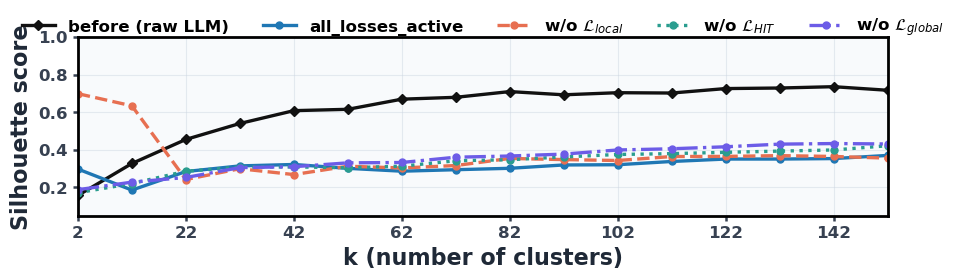


Saved single-table silhouette files:
 - silhouette_table_all_5_tables_qwen3-embedding#0.6b_all_variants.png
 - silhouette_table_all_5_tables_qwen3-embedding#0.6b_all_variants.pdf


In [19]:
# ── Silhouette score on Cell 10's spaces: raw vs every checkpoint variant ────
# Computes the silhouette curve directly on the point sets Cell 10 built for the
# visualised table (VIZ_TABLE_ID): `vecs_raw` (raw LLM, "before") plus every
# checkpoint's encoder output in `vecs_enc_by_variant`.  No re-embedding.

from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

# ── Guards ───────────────────────────────────────────────────────────────────
for _need in ("vecs_raw_all", "vecs_enc_by_variant_all"):
    if _need not in globals():
        raise RuntimeError(f"Run Cell 10 first ('{_need}' missing).")

_silh_tids = globals().get("VIZ_TABLE_IDS", [])
SILH_TABLE_ID = f"all_{len(_silh_tids)}_tables"

k_range = range(2, 153, 10)
N_COMPONENTS = 50

colors = ["#1f77b4", "#e76f51", "#2a9d8f", "#6c5ce7", "#f4a261", "#264653"]
linestyles = ["-", "--", ":", "-.", "-", "--"]
variant_order = ["all_losses_active", "local_off", "hit_off", "global_off"]
label_dict = {
    "all_losses_active": "all_losses_active",
    "local_off": r"w/o $\mathcal{L}_{local}$",
    "hit_off":   r"w/o $\mathcal{L}_{HIT}$",
    "global_off": r"w/o $\mathcal{L}_{global}$",
}
_ordered_keys = [v for v in variant_order if v in vecs_enc_by_variant_all] + [
    v for v in vecs_enc_by_variant_all if v not in variant_order
]

# space label -> (array, colour, linestyle, marker)  — stacked over ALL tables
spaces = {
    "before (raw LLM)": (np.asarray(vecs_raw_all, dtype=np.float32), "#111111", "-", "D"),
}
for _i, _key in enumerate(_ordered_keys):
    spaces[label_dict.get(_key, _key)] = (
        np.asarray(vecs_enc_by_variant_all[_key], dtype=np.float32),
        colors[_i % len(colors)],
        linestyles[_i % len(linestyles)],
        "o",
    )


def _silhouette_curve(emb: np.ndarray):
    emb = normalize(emb.astype(np.float32))
    n_comp = min(N_COMPONENTS, emb.shape[0], emb.shape[1])
    emb_reduced = PCA(n_components=n_comp, random_state=42).fit_transform(emb)
    max_k = min(max(k_range), emb_reduced.shape[0] - 1)
    if max_k < 2:
        return None, None
    ks = [k for k in k_range if k <= max_k]
    scores = []
    for k in ks:
        labels = KMeans(n_clusters=k, random_state=42, n_init="auto").fit_predict(emb_reduced)
        scores.append(silhouette_score(emb_reduced, labels, metric="cosine"))
    return ks, scores


fig, ax = plt.subplots(figsize=(10.0, 3), facecolor="white")
ax.set_facecolor("#f8fafc")

min_k_seen = float("inf")
max_k_seen = float("-inf")
n_plotted = 0
n_points = None

for label, (emb, color, ls, marker) in spaces.items():
    n_points = emb.shape[0]
    ks, scores = _silhouette_curve(emb)
    if ks is None:
        print(f"[skip] {label} - not enough points for silhouette analysis")
        continue
    min_k_seen = min(min_k_seen, min(ks))
    max_k_seen = max(max_k_seen, max(ks))
    n_plotted += 1
    ax.plot(
        ks,
        scores,
        label=label,
        color=color,
        linestyle=ls,
        linewidth=2.4,
        marker=marker,
        markersize=5,
    )

if n_plotted == 0:
    plt.close(fig)
    raise RuntimeError("No space had enough points to plot.")

x_min = int(min_k_seen)
x_max = int(max_k_seen)
ax.set_xlim(x_min, x_max)
ax.set_xticks(list(range(x_min, x_max + 1, 20)))
ax.set_ylim(0.05, 1.0)

ax.set_xlabel("k (number of clusters)", fontsize=16, color="#1f2937", fontweight="bold")
ax.set_ylabel("Silhouette score", fontsize=16, color="#1f2937", fontweight="bold")

ax.tick_params(colors="#374151", labelsize=12, width=1.8)
plt.setp(ax.get_xticklabels(), fontweight="bold")
plt.setp(ax.get_yticklabels(), fontweight="bold")
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(2.0)
ax.grid(alpha=0.45, color="#cbd5e1", linewidth=0.8)
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.20),
    ncol=min(len(spaces), 5),
    prop={"weight": "bold", "size": 12},
)

safe_tid = str(SILH_TABLE_ID).replace("/", "_")
print(f"Model name : {_sel_model_name!r}  —  {len(_group)} checkpoint variant(s)")
png_path = f"silhouette_table_{safe_tid}_{_sel_model_name.split('/')[-1].replace(':', '#')}_all_variants.png"
pdf_path = f"silhouette_table_{safe_tid}_{_sel_model_name.split('/')[-1].replace(':', '#')}_all_variants.pdf"
plt.tight_layout()
plt.savefig(pdf_path, dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.savefig(png_path, dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Stacked over {len(_silh_tids)} table(s) | points per space: {n_points} | spaces: {list(spaces.keys())}")
plt.show()

print("\nSaved single-table silhouette files:")
for p in (png_path, pdf_path):
    print(" -", p)
